In [ ]:
# Actual vs Forecast Consumption

**Objective:** Compare actual consumption against Prophet forecasts to evaluate model accuracy.

**Goal:** Quantify model performance and identify patterns.

**Building:** 17
**Model:** Prophet
**Forecast Horizon:** 48 hours

Connected to PostgreSQL successfully
Forecast period: 2025-01-01 00:45:00 to 2025-01-02 23:45:00
ACTUAL VS FORECAST (By Hour)
Rows: 48
                 hour  forecasted  actual
0 2025-01-01 00:00:00        1.12     1.2
1 2025-01-01 01:00:00        1.14     1.2
2 2025-01-01 02:00:00        1.12     1.2
3 2025-01-01 03:00:00        1.08     1.2
4 2025-01-01 04:00:00        1.07     1.2

MODEL PERFORMANCE
MAE: 0.21 kWh
MAPE: 12.93%


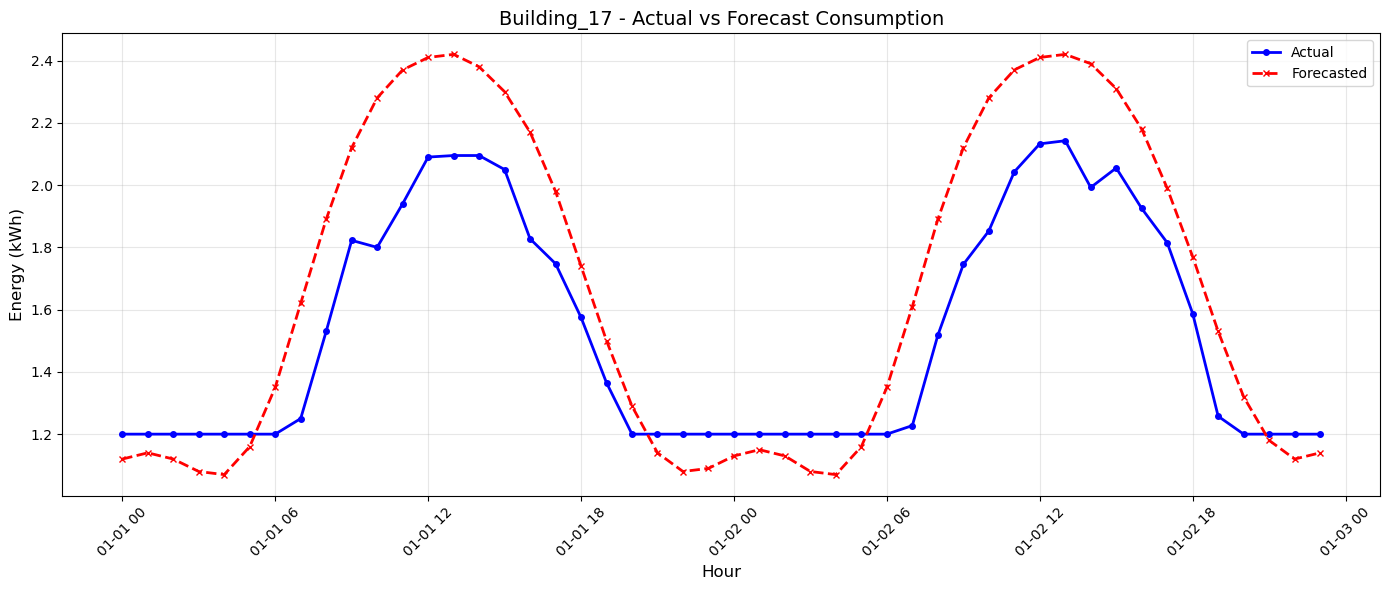

Connection closed


In [ ]:
# ============================================================
# ACTUAL VS FORECAST CONSUMPTION (FINAL WORKING)
# ============================================================

import os
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

os.environ['PYTHONIOENCODING'] = 'utf-8'
os.environ['PGCLIENTENCODING'] = 'UTF8'

conn = psycopg2.connect(
    host="localhost",
    database="energy_intelligence_project1",
    user="postgres",
    password="your_password_here",
    options="-c client_encoding=UTF8"
)
conn.set_client_encoding('UTF8')

print("Connected to PostgreSQL successfully")

# Step 1: Get forecast dates
forecast_dates = pd.read_sql("""
    SELECT MIN(forecast_timestamp) AS min_date, MAX(forecast_timestamp) AS max_date
    FROM energy_forecasts;
""", conn)

min_date = forecast_dates['min_date'].iloc[0]
max_date = forecast_dates['max_date'].iloc[0]

print(f"Forecast period: {min_date} to {max_date}")

# Step 2: Load actual vs forecast by HOUR
query = """
WITH hourly_actual AS (
    SELECT 
        DATE_TRUNC('hour', timestamp) AS hour,
        AVG(energy_kwh) AS actual_avg
    FROM energy_readings
    WHERE building_id = 17
    AND timestamp >= DATE_TRUNC('hour', %s::timestamp)
    AND timestamp <= DATE_TRUNC('hour', %s::timestamp) + INTERVAL '2 days'
    GROUP BY DATE_TRUNC('hour', timestamp)
),
hourly_forecast AS (
    SELECT 
        DATE_TRUNC('hour', forecast_timestamp) AS hour,
        AVG(forecast_energy_kwh) AS forecast_avg
    FROM energy_forecasts
    WHERE building_id = 17
    GROUP BY DATE_TRUNC('hour', forecast_timestamp)
)
SELECT 
    hf.hour AS hour,
    hf.forecast_avg AS forecasted,
    ha.actual_avg AS actual
FROM hourly_forecast hf
LEFT JOIN hourly_actual ha ON hf.hour = ha.hour
ORDER BY hf.hour;
"""

df = pd.read_sql(query, conn, params=[min_date, max_date])

# Fix negative values
df['forecasted'] = df['forecasted'].clip(lower=0)

print("=" * 60)
print("ACTUAL VS FORECAST (By Hour)")
print("=" * 60)
print(f"Rows: {len(df):,}")
print(df.head())

if len(df) > 0:
    # Remove rows with missing actual data
    df_clean = df.dropna(subset=['actual'])
    
    if len(df_clean) > 0:
        mae = mean_absolute_error(df_clean['actual'], df_clean['forecasted'])
        mape = mean_absolute_percentage_error(df_clean['actual'], df_clean['forecasted']) * 100
        
        print("\n" + "=" * 60)
        print("MODEL PERFORMANCE")
        print("=" * 60)
        print(f"MAE: {mae:.2f} kWh")
        print(f"MAPE: {mape:.2f}%")
        
        plt.figure(figsize=(14, 6))
        plt.plot(df_clean['hour'], df_clean['actual'], 
                 label='Actual', color='blue', linewidth=2, marker='o', markersize=4)
        plt.plot(df_clean['hour'], df_clean['forecasted'], 
                 label='Forecasted', color='red', linestyle='--', linewidth=2, marker='x', markersize=4)
        plt.title('Building_17 - Actual vs Forecast Consumption', fontsize=14)
        plt.xlabel('Hour', fontsize=12)
        plt.ylabel('Energy (kWh)', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("No actual data available for the forecast period.")
else:
    print("No forecasts found.")

conn.close()
print("Connection closed")